<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Подключение к MLFow

In [1]:
pip install -q dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 102.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import dagshub
import mlflow
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["DAGSHUB_CLIENT_TOKEN"] = user_secrets.get_secret("DAGSHUB_TOKEN")

dagshub.init(repo_owner="egrsid", repo_name="skin_cancer_segmentation", mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9eafc94f-8a47-4ba6-93ca-a2ab3d98117d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=028a4f859fd1a4caff41ce0665d5486363cede670eebeee9495f0e4d1116ac9e




Accessing as egrsid

Initialized MLflow to track repo "egrsid/skin_cancer_segmentation"

Repository egrsid/skin_cancer_segmentation initialized!

# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>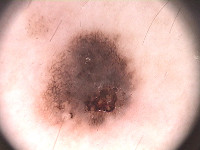</td><td>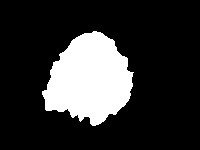</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [3]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=a4ab62dd-3ef4-4d2d-9c11-04ce7e752efc
To: /kaggle/working/PH2Dataset.rar
100%|████████████████████████████████████████| 162M/162M [00:04<00:00, 37.9MB/s]


In [4]:
get_ipython().system_raw("unrar x PH2Dataset.rar")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from PH2Dataset.rar

Creating    PH2Dataset                                                OK
Creating    PH2Dataset/PH2 Dataset images                             OK
Creating    PH2Dataset/PH2 Dataset images/IMD002                      OK
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image  OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image/IMD002.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion        OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion/IMD002_lesion.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi           OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R1_Label4.bmp     0  OK 
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R2_Label3.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD003                      OK
Crea

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [172]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [173]:
for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

In [174]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

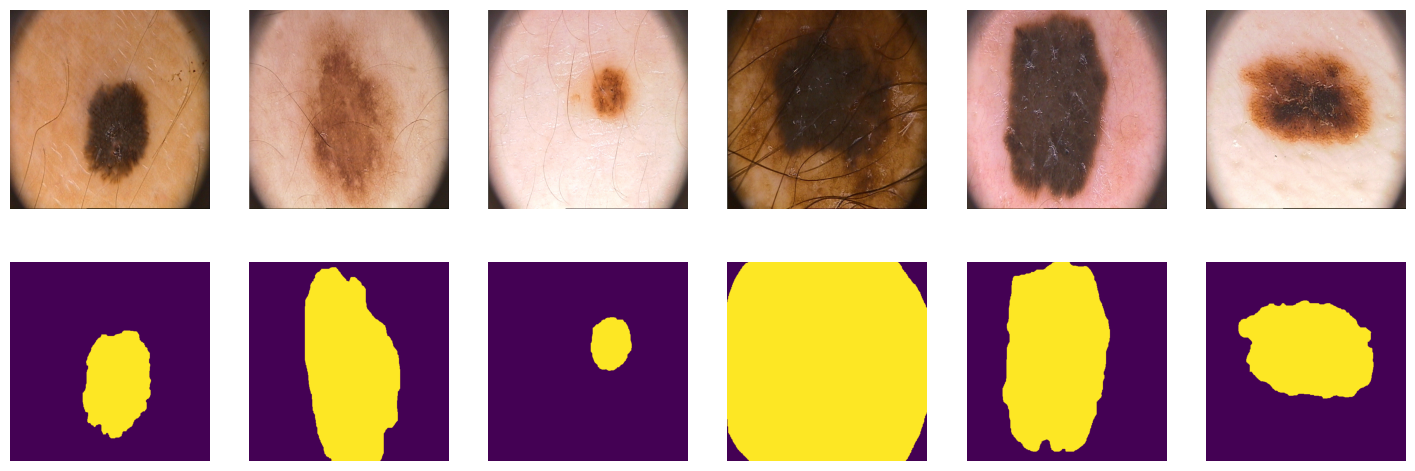

In [12]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [175]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [14]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [16]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.6 MB/s eta 0:00:00


In [176]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp

In [177]:
preprocessing_fn = smp.encoders.get_preprocessing_params("resnet34")

In [178]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Аугментации для обучающей выборки (Train)
train_transform = A.Compose(
    [
        # Геометрические аугментации (DualTransform)
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        # Замена ShiftScaleRotate на Affine
        A.Affine(
            scale=(0.9, 1.1),
            translate_percent=(-0.0625, 0.0625),
            rotate=(-45, 45),
            p=0.5,
        ),
        A.ElasticTransform(alpha=1, sigma=50, p=0.3),
        # Цветовые аугментации (ImageOnlyTransform)
        A.RandomBrightnessContrast(
            brightness_limit=0.2, contrast_limit=0.2, p=0.5
        ),
        A.HueSaturationValue(
            hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3
        ),
        # GaussNoise с новым синтаксисом std_range
        A.GaussNoise(std_range=(0.02, 0.1), p=0.3),
        # Нормализация
        A.Normalize(
            mean=preprocessing_fn["mean"],
            std=preprocessing_fn["std"],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

# Преобразования для валидации и теста (БЕЗ случайных аугментаций)
val_transform = A.Compose(
    [
        A.Normalize(
            mean=preprocessing_fn["mean"],
            std=preprocessing_fn["std"],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

In [179]:
class SegmentationDataset(Dataset):

    def __init__(self, images, masks, transform=None):
        """
        images: numpy array формы (N, H, W, C)
        masks:  numpy array формы (N, H, W) или (N, H, W, 1)
        """
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        # Гарантируем правильный тип для Albumentations (uint8 для RGB 0..255)
        if image.dtype != np.uint8 and image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        elif image.dtype != np.uint8:
            image = image.astype(np.uint8)

        mask = mask.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).float()

        # Добавляем размерность канала маски [H, W] -> [1, H, W], если нужно
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.permute(2, 0, 1)

        # Маска должна быть в диапазоне [0.0, 1.0]
        if mask.max() > 1.0:
            mask = mask / 255.0

        return image, mask

In [227]:
# Создаем датасеты с аугментациями
train_ds = SegmentationDataset(X[tr], Y[tr], transform=train_transform)
val_ds = SegmentationDataset(X[val], Y[val], transform=val_transform)
test_ds = SegmentationDataset(X[ts], Y[ts], transform=val_transform)

train_batch_size = 16 
val_batch_size = 36
test_batch_size = 10

# num_workers=2 и persistent_workers=True ускоряют генерацию аугментаций на CPU
train_loader = DataLoader(
    train_ds,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=val_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=test_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

In [22]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, "num devices:", torch.cuda.device_count())

cuda num devices: 2


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [ ]:
def bce_loss(y_pred, y_real):
    return torch.sum(y_pred - y_pred * y_real + torch.log(1 + torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
    return -torch.sum(
        y_real * torch.log(torch.sigmoid(y_pred)) +
        (1 - y_real) * torch.log(1 - torch.sigmoid(y_pred))
    )

Проверим корректность работы на простом примере

In [ ]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [ ]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [34]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /kaggle/working/for_asserts/labels.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 5.16MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /kaggle/working/for_asserts/logits.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 4.50MB/s]
Download completed


In [35]:
path_to_dummy_samples = '/kaggle/working/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

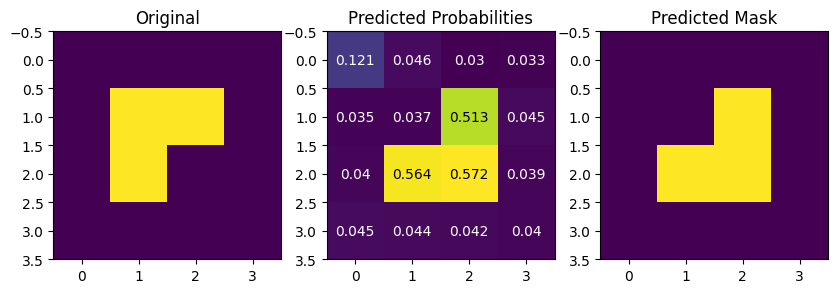

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [ ]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

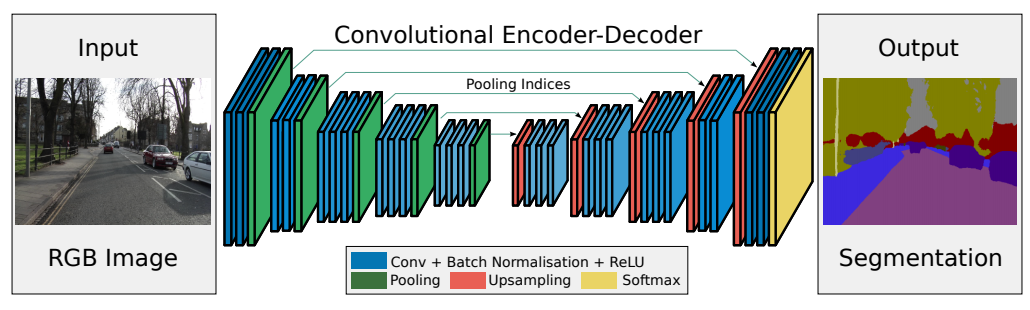

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [ ]:
model_vgg16

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [ ]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super().__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, is_last=False):
        super().__init__()

        self.layers = nn.ModuleList()
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = in_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        if not is_last:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.upsample = nn.MaxUnpool2d(kernel_size=2, stride=2)

    def forward(self, x, indices):
        x = self.upsample(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super().__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, is_last=True)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 =  self.encoder1(x)
        x, indices2 =  self.encoder2(x)
        x, indices3 =  self.encoder3(x)
        x, indices4 =  self.encoder4(x)

        # decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)

        output = self.decoder4(x, indices0)
        return output  # no activation

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

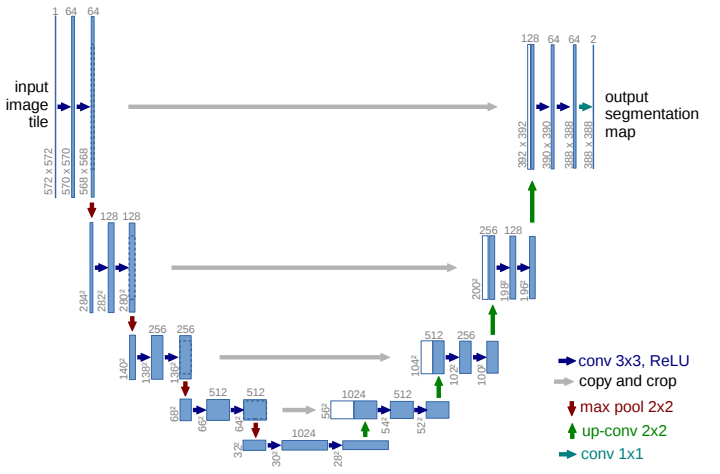

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
class UNetConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, stride=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class UNetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = UNetConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.block(x)
        return x, self.pool(x)

class UNetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = UNetConvBlock(in_channels, out_channels)
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2, padding=0, bias=True)

    def forward(self, x, y):
        y = self.transpose(y)
        x = torch.cat([x, y], dim=1)
        return self.block(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.encoder1 = UNetEncoderBlock(in_channels, 64)
        self.encoder2 = UNetEncoderBlock(64, 128)
        self.encoder3 = UNetEncoderBlock(128, 256)
        self.encoder4 = UNetEncoderBlock(256, 512)

        self.bottleneck = UNetConvBlock(512, 1024)

        self.decoder1 = UNetDecoderBlock(1024, 512)
        self.decoder2 = UNetDecoderBlock(512, 256)
        self.decoder3 = UNetDecoderBlock(256, 128)
        self.decoder4 = UNetDecoderBlock(128, 64)

        self.final_mask = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        y1, x = self.encoder1(x)
        y2, x = self.encoder2(x)
        y3, x = self.encoder3(x)
        y4, x = self.encoder4(x)
        
        x = self.bottleneck(x)

        x = self.decoder1(y4, x)
        x = self.decoder2(y3, x)
        x = self.decoder3(y2, x)
        x = self.decoder4(y1, x)

        return self.final_mask(x)

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [24]:
from tqdm.auto import tqdm
from pathlib import Path

CHECKPOINT_DIR = Path("kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
def train_one_epoch(model, x_train, y_train, loss_func, optimizer, device):
    x_train, y_train = x_train.to(device), y_train.to(device)

    predict = model(x_train)
    loss = loss_func(predict, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        if predict.shape[1] == 1:
            pred_mx_idx = (predict.sigmoid() > 0.5).float()
        else:
            pred_mx_idx = predict.argmax(dim=1)

    # Возвращаем чистый float для loss, чтобы не держать граф вычислений и VRAM
    return loss.item(), pred_mx_idx, y_train

In [26]:
def test_one_epoch(model, x_test, y_test, loss_func, device):
    x_test, y_test = x_test.to(device), y_test.to(device)

    with torch.no_grad():
        pred = model(x_test)
        loss = loss_func(pred, y_test)

        if pred.shape[1] == 1:
            pred_mx_idx = (pred.sigmoid() > 0.5).float()
        else:
            pred_mx_idx = pred.argmax(dim=1)

    return loss.item(), pred_mx_idx, y_test

In [27]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    loss_func,
    optimizer,
    lr_scheduler,
    name_to_save,
    checkpoint_dir,
    patience=3,
    training_all_dataset=False,
    score_func=None,
    device=torch.device("cuda"),
):

    os.makedirs(checkpoint_dir, exist_ok=True)

    train_losses, val_losses = [], []
    train_scores, val_scores = [], []
    epochs_without_impact = 0
    best_checkpoint_path = None
    best_val_score = 0.0
    best_val_loss = float("inf")

    # 1. Запуск эксперимента в MLflow
    with mlflow.start_run(run_name=name_to_save):
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("optimizer_name", type(optimizer).__name__)
        mlflow.log_param("initial_lr", optimizer.param_groups[0]["lr"])
        mlflow.log_param("loss_function", type(loss_func).__name__)

        try:
            for _e in range(epochs):
                # --- ТРЕНИРОВКА ---
                model.train()
                train_loss_acc = 0.0
                train_score_acc = 0.0

                pbar_train = tqdm(
                    train_loader,
                    desc=f"Epoch {_e+1}/{epochs} [Train]",
                    leave=False,
                )
                for x_tr, y_tr in pbar_train:
                    loss_val, preds, targets = train_one_epoch(
                        model, x_tr, y_tr, loss_func, optimizer, device
                    )
                    train_loss_acc += loss_val

                    if score_func:
                        s_val = score_func(preds, targets)
                        s_val = (
                            s_val.item()
                            if isinstance(s_val, torch.Tensor)
                            else s_val
                        )
                        train_score_acc += s_val
                        pbar_train.set_postfix(
                            {
                                "loss": f"{loss_val:.4f}",
                                f"{score_func.__name__}": f"{s_val:.4f}",
                            }
                        )
                    else:
                        pbar_train.set_postfix({"loss": f"{loss_val:.4f}"})

                avg_train_loss = train_loss_acc / len(train_loader)
                train_losses.append(avg_train_loss)
                if score_func:
                    avg_train_score = train_score_acc / len(train_loader)
                    train_scores.append(avg_train_score)

                # --- ВАЛИДАЦИЯ ---
                model.eval()
                val_loss_acc = 0.0
                val_score_acc = 0.0

                pbar_val = tqdm(
                    val_loader,
                    desc=f"Epoch {_e+1}/{epochs} [Val]",
                    leave=False,
                )
                for x_v, y_v in pbar_val:
                    loss_val, preds, targets = test_one_epoch(
                        model, x_v, y_v, loss_func, device
                    )
                    val_loss_acc += loss_val

                    if score_func:
                        s_val = score_func(preds, targets)
                        s_val = (
                            s_val.item()
                            if isinstance(s_val, torch.Tensor)
                            else s_val
                        )
                        val_score_acc += s_val
                        pbar_val.set_postfix(
                            {
                                "loss": f"{loss_val:.4f}",
                                f"{score_func.__name__}": f"{s_val:.4f}",
                            }
                        )
                    else:
                        pbar_val.set_postfix({"loss": f"{loss_val:.4f}"})

                avg_val_loss = val_loss_acc / len(val_loader)
                val_losses.append(avg_val_loss)
                if score_func:
                    avg_val_score = val_score_acc / len(val_loader)
                    val_scores.append(avg_val_score)

                # --- ПЛАНИРОВЩИК LR ---
                current_lr = optimizer.param_groups[0]["lr"]
                if lr_scheduler:
                    if isinstance(
                        lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
                    ):
                        lr_scheduler.step(
                            avg_val_score if score_func else avg_val_loss
                        )
                    else:
                        lr_scheduler.step()

                # --- ЛОГИРОВАНИЕ МЕТРИК В MLFLOW ---
                mlflow.log_metric("train_loss", avg_train_loss, step=_e)
                mlflow.log_metric("val_loss", avg_val_loss, step=_e)
                mlflow.log_metric("learning_rate", current_lr, step=_e)
                if score_func:
                    mlflow.log_metric(
                        f"train_{score_func.__name__}", avg_train_score, step=_e
                    )
                    mlflow.log_metric(
                        f"val_{score_func.__name__}", avg_val_score, step=_e
                    )

                # Печать итогов эпохи
                print(
                    f"Epoch {_e+1:02d}/{epochs} | "
                    f"Train Loss: {avg_train_loss:.4f} | "
                    f"Val Loss: {avg_val_loss:.4f}"
                    + (
                        f" | Val {score_func.__name__}: {avg_val_score:.4f}"
                        if score_func
                        else ""
                    )
                )

                # --- ПРОВЕРКА НА ЛУЧШУЮ МОДЕЛЬ ---
                is_best = False
                current_score = avg_val_score if score_func else -avg_val_loss

                if _e == 0 or (
                    score_func and current_score >= best_val_score + 0.002
                ):
                    if score_func:
                        best_val_score = current_score
                    best_val_loss = avg_val_loss
                    epochs_without_impact = 0
                    is_best = True
                elif avg_val_loss <= best_val_loss - 0.002:
                    best_val_loss = avg_val_loss
                    epochs_without_impact = 0
                    is_best = True
                else:
                    epochs_without_impact += 1

                # Сохраняем локальный чекпоинт на диск
                if is_best or training_all_dataset:
                    ckpt_type = "train" if training_all_dataset else "val"
                    score_str = (
                        f"_score{avg_val_score:.4f}" if score_func else ""
                    )
                    checkpoint_name = (
                        f"{name_to_save}_{ckpt_type}_ep{_e+1}{score_str}.pt"
                    )
                    best_checkpoint_path = os.path.join(
                        checkpoint_dir, checkpoint_name
                    )

                    raw_state = (
                        model.module.state_dict()
                        if isinstance(model, nn.DataParallel)
                        else model.state_dict()
                    )
                    torch.save(raw_state, best_checkpoint_path)

                # Проверка Early Stopping
                if epochs_without_impact >= patience:
                    print(
                        f"\n[Early Stopping] Обучение остановлено на эпохе {_e+1}. Нет улучшений {patience} эпох."
                    )
                    break

        except KeyboardInterrupt:
            print(
                "\n[Внимание] Обучение прервано пользователем вручную (KeyboardInterrupt)!"
            )
        except Exception as e:
            print(f"\n[Ошибка во время обучения]: {e}")
            raise e
        finally:
            # 1. Отправляем в MLflow гарантированно лучший чекпоинт
            if best_checkpoint_path and os.path.exists(best_checkpoint_path):
                print(
                    f"\n-> Отправка лучшего чекпоинта в MLflow: {best_checkpoint_path}"
                )
                mlflow.log_artifact(best_checkpoint_path)

            # 2. Логируем итоговый тег с лучшим скором
            if score_func:
                mlflow.set_tag(
                    f"best_val_{score_func.__name__}", f"{best_val_score:.4f}"
                )
            mlflow.set_tag("best_val_loss", f"{best_val_loss:.4f}")
            print("Сессия рана MLflow корректно завершена.")

    # 3. Загружаем веса лучшей эпохи обратно в модель перед возвратом
    if best_checkpoint_path and os.path.exists(best_checkpoint_path):
        print(
            f"Загрузка лучших весов ({best_checkpoint_path}) в модель для инференса..."
        )
        best_state = torch.load(best_checkpoint_path, map_location=device)
        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(best_state)
        else:
            model.load_state_dict(best_state)

    return model, (train_losses, train_scores, val_losses, val_scores)

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

## Кастомный лосс

In [28]:
class DiceLossCustom(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, predict, y_true):
        n = predict.shape[0]  # размер батча
        pr = torch.sigmoid(predict).view(n, -1)
        gt = y_true.view(n, -1)

        interception = (pr * gt).sum(dim=1)
        union = pr.sum(dim=1) + gt.sum(dim=1)
        inverced_score = (2 * interception + self.smooth) / (union + self.smooth)

        return (1 - inverced_score).mean()

In [29]:
class BinaryFocalLoss(nn.Module):

    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """logits: [B, 1, H, W] или [B, C, ...] (сырые выходы модели до

        сигмоиды) targets: [B, 1, H, W] или [B, C, ...] (бинарные метки 0 или
        1)
        """
        # Считаем стандартный BCE с reduction='none'
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        # Вычисляем p_t (вероятность правильного класса)
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)

        # Фокусирующий множитель
        focal_weight = (1.0 - p_t) ** self.gamma

        # Балансирующий множитель alpha
        if self.alpha is not None and self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [30]:
class CustomLoss(nn.Module):
    def __init__(self, bce_func, dice_func, alpha=0.5, beta=0.5):
        super().__init__()
        self.bce_func = bce_func
        self.dice_func = dice_func
        self.alpha = alpha
        self.beta = beta

    def forward(self, predict, y_true):
        bce_loss = self.bce_func(predict, y_true)
        dice_loss = self.dice_func(predict, y_true)

        return self.alpha * bce_loss + self.beta * dice_loss

In [31]:
!pip install segmentation_models_pytorch
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

NameError: name 'dummpy_sample' is not defined

In [37]:
assert np.isclose(dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']).cpu(), DiceLossCustom()(dummpy_sample['logits'], dummpy_sample['labels']).cpu())

In [38]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [39]:
assert np.isclose(sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').cpu(), BinaryFocalLoss(alpha=-1, gamma=2, reduction='sum')(dummpy_sample['logits'], dummpy_sample['labels']).cpu())

## Кастомный score

In [40]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

In [41]:
class IoUScore(nn.Module):
    def __init__(self, iou_func):
        super().__init__()
        self.iou_func = iou_func
        self.__name__ = "IoU"

    def forward(self, predict, y_true):
        with torch.no_grad():
            # Явно приводим к вероятностям, если predict похож на логиты
            if predict.min() < 0 or predict.max() > 1:
                predict = torch.sigmoid(predict)
            return self.iou_func(predict, y_true)

In [42]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='macro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

# Обучение моделей

### Segnet default

In [ ]:
model = SegNet().to(device)
if torch.cuda.device_count() > 1:
    print("Обучение распределено на 2x GPU T4!")
    model = nn.DataParallel(model)

In [ ]:
import torchsummary
torchsummary.summary(model.module, (3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLoss(), alpha=0.3, beta=0.7)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
score_func = IoUScore(iou_score)

In [ ]:
model_segnet_default, data_plot = train_model(
    model, train_loader, val_loader, 20,
    loss_func, optimizer, lr_scheduler, "segnet_default20epochs",
    CHECKPOINT_DIR, score_func=score_func
)

### UNet default

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
import torchsummary
torchsummary.summary(model, (3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLoss(), alpha=0.3, beta=0.7)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_default, data_plot = train_model(
    model, train_loader, val_loader, 30,
    loss_func, optimizer, lr_scheduler, "unet_default30epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### UNet trained on data with augmentations

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLoss(), alpha=0.6, beta=0.4)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=3e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_default, data_plot = train_model(
    model, train_loader, val_loader, 100,
    loss_func, optimizer, lr_scheduler, "unet_augmented100epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### Unet augments + focal loss

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
loss_func = CustomLoss(BinaryFocalLoss(alpha=0.25, gamma=2.0, reduction="mean"), DiceLoss(), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_default, data_plot = train_model(
    model, train_loader, val_loader, 100,
    loss_func, optimizer, lr_scheduler, "unet_augmented_focal100epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### Unet augments + focal loss + adjust params

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
loss_func = CustomLoss(BinaryFocalLoss(alpha=0.20, gamma=2.0, reduction="mean"), DiceLoss(), alpha=0.4, beta=0.6)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=6e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=6e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_default, data_plot = train_model(
    model, train_loader, val_loader, 100,
    loss_func, optimizer, lr_scheduler, "unet_augmented_focal_0.4_0.6cl100epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### UNet dilated inception bottleneck

In [ ]:
class UNetDilatedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            # padding = dilation для сохранения размерности карты признаков
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.encoder1 = UNetEncoderBlock(in_channels, 64)
        self.encoder2 = UNetEncoderBlock(64, 128)
        self.encoder3 = UNetEncoderBlock(128, 256)
        self.encoder4 = UNetEncoderBlock(256, 512)

        self.bottleneck1 = UNetDilatedBlock(512, 256, dilation=1)
        self.bottleneck2 = UNetDilatedBlock(512, 256, dilation=2)
        self.bottleneck3 = UNetDilatedBlock(512, 256, dilation=3)
        self.bottleneck4 = UNetDilatedBlock(512, 256, dilation=4)

        self.decoder1 = UNetDecoderBlock(1024, 512)
        self.decoder2 = UNetDecoderBlock(512, 256)
        self.decoder3 = UNetDecoderBlock(256, 128)
        self.decoder4 = UNetDecoderBlock(128, 64)

        self.final_mask = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        y1, x = self.encoder1(x)
        y2, x = self.encoder2(x)
        y3, x = self.encoder3(x)
        y4, x = self.encoder4(x)

        bnr1 = self.bottleneck1(x)
        bnr2 = self.bottleneck2(x)
        bnr3 = self.bottleneck3(x)
        bnr4 = self.bottleneck4(x)
        x = torch.cat([bnr1, bnr2, bnr3, bnr4], dim=1)

        x = self.decoder1(y4, x)
        x = self.decoder2(y3, x)
        x = self.decoder3(y2, x)
        x = self.decoder4(y1, x)

        return self.final_mask(x)

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
import torchsummary
torchsummary.summary(model.module, (3, 256, 256))

In [ ]:
loss_func = CustomLoss(BinaryFocalLoss(alpha=0.30, gamma=2.0, reduction="mean"), DiceLoss(), alpha=0.6, beta=0.4)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=6e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=6e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_default, data_plot = train_model(
    model, train_loader, val_loader, 100,
    loss_func, optimizer, lr_scheduler, "unet_dilated_augmented_focal_0.6_0.4cl100epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### UNet dilated inception bottleneck + back to BCE loss

In [ ]:
model = UNet(in_channels=3, out_channels=1).to(device)
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLoss(), alpha=0.6, beta=0.4)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=6e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=6e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_back_bce, data_plot = train_model(
    model, train_loader, val_loader, 100,
    loss_func, optimizer, lr_scheduler, "unet_dilated_augmented_bce_0.6_0.4cl100epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

### UNet дообучение сети, обученной на bce, с помощью focal

In [ ]:
loss_func = CustomLoss(BinaryFocalLoss(alpha=0.40, gamma=2.0, reduction="mean"), DiceLoss(), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=model_unet_back_bce.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=5e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_back_bce, data_plot = train_model(
    model, train_loader, val_loader, 40,
    loss_func, optimizer, lr_scheduler, "unet_dilated_augmented_bce_focal_0.5_0.5cl40epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

### UNet дообучение на bce + снижение вклада bce

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLoss(), alpha=0.35, beta=0.65)
optimizer = torch.optim.AdamW(params=model_unet_back_bce.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=5e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_back_bce, data_plot = train_model(
    model, train_loader, val_loader, 40,
    loss_func, optimizer, lr_scheduler, "unet_dilated_augmented_bce_focal__bce_0.35_0.65cl40epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

### UNet с предобученным encoder на ImageNet

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

для соответствия распределений входной картинки изменены mean, std в лоадерах, изменен denormalize для теста

#### Этап 1 - обучение только декодера (разогрев)

In [ ]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

In [ ]:
model.module.encoder.requires_grad_(False)
import torchinfo
torchinfo.summary(model.module, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLossCustom(), alpha=0.35, beta=0.65)
optimizer = torch.optim.AdamW(params=[param for param in model.parameters() if param.requires_grad], 
                              lr=3e-4, 
                              weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_unet_back_bce, data_plot = train_model(
    model, train_loader, val_loader, 5,
    loss_func, optimizer, lr_scheduler, "unet_pretrained_decoder_head_bce_0.35_0.65cl5epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

#### Шаг 2 - дообучение всей модели

In [ ]:
model_unet_back_bce.module.requires_grad_(True)
torchinfo.summary(model_unet_back_bce, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLossCustom(), alpha=0.35, beta=0.65)
optimizer = torch.optim.AdamW(
    [
        {
            "params": model_unet_back_bce.module.encoder.parameters(),
            "lr": 1e-5,
        },  # энкодер учим деликатно
        {
            "params": model_unet_back_bce.module.decoder.parameters(),
            "lr": 1e-4,
        },  # декодер учим активнее
        {"params": model_unet_back_bce.module.segmentation_head.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4,
)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 50,
    loss_func, optimizer, lr_scheduler, "unet_pretrained_all_bce_0.35_0.65cl5epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=8
)

## UNet++

In [ ]:
model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

In [ ]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

#### Шаг 1 - разогрев

In [ ]:
model.module.encoder.requires_grad_(False)
torchinfo.summary(model.module, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLossCustom(), alpha=0.4, beta=0.6)
optimizer = torch.optim.AdamW(params=[param for param in model.parameters() if param.requires_grad], 
                              lr=3e-4, 
                              weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 7,
    loss_func, optimizer, lr_scheduler, "unetPlusPlus_pretrained_decoder_head_bce_0.4_0.6cl7epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

#### Шаг 2 - полное дообучение

In [ ]:
model.module.requires_grad_(True)
torchinfo.summary(model.module, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLossCustom(), alpha=0.4, beta=0.6)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 5e-4
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=5e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 50,
    loss_func, optimizer, lr_scheduler, "unetPlusPlus_pretrained_all_bce_0.4_0.6cl50epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

### DeepLabV3+

In [105]:
model = smp.DeepLabV3Plus(encoder_name="resnet101", encoder_weights="imagenet", in_channels=3, classes=1)

In [106]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

Train on 2 GPUs


#### Шаг 1 - разогрев

In [107]:
model.module.encoder.requires_grad_(False)
torchinfo.summary(model.module, (1, 3, 256, 256))

Layer (type:depth-idx)                                  Output Shape              Param #
DeepLabV3Plus                                           [1, 1, 256, 256]          --
├─ResNetEncoder: 1-1                                    [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                                      [1, 64, 128, 128]         (9,408)
│    └─BatchNorm2d: 2-2                                 [1, 64, 128, 128]         (128)
│    └─ReLU: 2-3                                        [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                                   [1, 64, 64, 64]           --
│    └─Sequential: 2-5                                  [1, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                             [1, 256, 64, 64]          (75,008)
│    │    └─Bottleneck: 3-2                             [1, 256, 64, 64]          (70,400)
│    │    └─Bottleneck: 3-3                             [1, 256, 64, 64]          (70,400)
│    └─Sequential: 2-6            

In [108]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.4, beta=0.6)
optimizer = torch.optim.AdamW(params=[param for param in model.parameters() if param.requires_grad], 
                              lr=3e-4, 
                              weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [109]:
model, data_plot = train_model(
    model, train_loader, val_loader, 7,
    loss_func, optimizer, lr_scheduler, "DeepLabV3Plus101_pretrained_decoder_head_bce_lovasz_0.4_0.6cl7epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

Epoch 1/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/7 | Train Loss: 0.7463 | Val Loss: 0.8915 | Val IoU: 0.0464


Epoch 2/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 2/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 6/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 06/7 | Train Loss: 0.3737 | Val Loss: 0.4369 | Val IoU: 0.7704


Epoch 7/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 7/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 07/7 | Train Loss: 0.3735 | Val Loss: 0.4212 | Val IoU: 0.7734

-> Отправка лучшего чекпоинта в MLflow: kaggle/working/checkpoints/DeepLabV3Plus101_pretrained_decoder_head_bce_lovasz_0.4_0.6cl7epochs_val_ep7_score0.7734.pt
Сессия рана MLflow корректно завершена.
🏃 View run DeepLabV3Plus101_pretrained_decoder_head_bce_lovasz_0.4_0.6cl7epochs at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0/runs/300af8c9889243b4a37fbc54e50923e4
🧪 View experiment at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0
Загрузка лучших весов (kaggle/working/checkpoints/DeepLabV3Plus101_pretrained_decoder_head_bce_lovasz_0.4_0.6cl7epochs_val_ep7_score0.7734.pt) в модель для инференса...


#### Шаг 2 - дообучение всей модели

In [110]:
model.module.requires_grad_(True);
torchinfo.summary(model.module, (1, 3, 256, 256))

Layer (type:depth-idx)                                  Output Shape              Param #
DeepLabV3Plus                                           [1, 1, 256, 256]          --
├─ResNetEncoder: 1-1                                    [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                                      [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                                 [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                        [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                                   [1, 64, 64, 64]           --
│    └─Sequential: 2-5                                  [1, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                             [1, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                             [1, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                             [1, 256, 64, 64]          70,400
│    └─Sequential: 2-6                      

In [112]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.4, beta=0.6)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 5e-4
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [113]:
model, data_plot = train_model(
    model, train_loader, val_loader, 80,
    loss_func, optimizer, lr_scheduler, "DeepLabV3Plus101_pretrained_all_bce_lovasz_0.4_0.6cl80epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

Epoch 1/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/80 | Train Loss: 0.4187 | Val Loss: 0.4681 | Val IoU: 0.7622


Epoch 2/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 2/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 17/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 17/80 | Train Loss: 0.1844 | Val Loss: 0.2966 | Val IoU: 0.8576


Epoch 18/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 18/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 18/80 | Train Loss: 0.2092 | Val Loss: 0.3097 | Val IoU: 0.8573

[Early Stopping] Обучение остановлено на эпохе 18. Нет улучшений 10 эпох.

-> Отправка лучшего чекпоинта в MLflow: kaggle/working/checkpoints/DeepLabV3Plus101_pretrained_all_bce_lovasz_0.4_0.6cl80epochs_val_ep8_score0.8647.pt
Сессия рана MLflow корректно завершена.
🏃 View run DeepLabV3Plus101_pretrained_all_bce_lovasz_0.4_0.6cl80epochs at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0/runs/9e53a04ef1314c33a7d9088f759a3c88
🧪 View experiment at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0
Загрузка лучших весов (kaggle/working/checkpoints/DeepLabV3Plus101_pretrained_all_bce_lovasz_0.4_0.6cl80epochs_val_ep8_score0.8647.pt) в модель для инференса...


#### Попробуем дообучить с акцентом на bce

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), DiceLossCustom(), alpha=0.6, beta=0.4)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 5e-4
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=3e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 80,
    loss_func, optimizer, lr_scheduler, "DeepLabV3Plus_pretrained_all_bce_0.6_0.4cl80epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

### UNet++ se_resnext50_32x4d backbone + Lovasz Loss

In [ ]:
model = smp.UnetPlusPlus(
    encoder_name="se_resnext50_32x4d",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

In [ ]:
if torch.cuda.device_count() > 1:
    print("Train on 2 GPUs")
    model = nn.DataParallel(model)

#### Шаг 1 - разогрев

In [ ]:
model.module.encoder.requires_grad_(False)
torchinfo.summary(model.module, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=[param for param in model.parameters() if param.requires_grad], 
                              lr=3e-4, 
                              weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 7,
    loss_func, optimizer, lr_scheduler, "UNet_resnext50_decoder_head_bce_lovasz_0.5_0.5cl7epochs",
    CHECKPOINT_DIR, score_func=score_func.to(device), patience=7
)

#### Шаг 2 - дообучение всей модели

In [ ]:
model.module.requires_grad_(True)
torchinfo.summary(model.module, (1, 3, 256, 256))

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 1e-4
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 80,
    loss_func, optimizer, lr_scheduler, "UNet_resnext50_all_bce_lovasz_0.5_0.5cl80epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

### UNet++ BCE+Dice за основу, дообучение на BCE+Lovasz

In [ ]:
RUN_ID = "41740b3972a146dab8e9c8e0c90f6807"
ARTIFACT_NAME = "unetPlusPlus_pretrained_all_bce_0.4_0.6cl50epochs_val_ep30_score0.9133.pt"
DOWNLOAD_DIR = "/kaggle/working/downloaded_models"

client = mlflow.tracking.MlflowClient()
local_weight_path = client.download_artifacts(
    run_id=RUN_ID,
    path=ARTIFACT_NAME,
    dst_path=DOWNLOAD_DIR
)

In [ ]:
state_dict = torch.load(local_weight_path, map_location=device)
model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model.load_state_dict(state_dict)
model = model.to(device)

##### Заменяем BN на SyncBN

In [ ]:
if torch.cuda.device_count() > 1:
    print("Обучение распределено на 2x GPU T4!")
    model = nn.SyncBatchNorm.convert_sync_batchnorm(model)
    model = nn.DataParallel(model)

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.45, beta=0.55)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 3e-4
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model, data_plot = train_model(
    model, train_loader, val_loader, 50,
    loss_func, optimizer, lr_scheduler, "UNet_resnet34_all_after_dice_bce_lovasz_0.45_0.55cl80epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

### UNet искусственное увеличение размерности входной картинки до 512х512

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

from skimage.transform import resize
size = (512, 512)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)

ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

# Создаем датасеты с аугментациями
train_ds = SegmentationDataset(X[tr], Y[tr], transform=train_transform)
val_ds = SegmentationDataset(X[val], Y[val], transform=val_transform)
test_ds = SegmentationDataset(X[ts], Y[ts], transform=val_transform)

train_batch_size = 16 
val_batch_size = 32

# num_workers=2 и persistent_workers=True ускоряют генерацию аугментаций на CPU
train_loader = DataLoader(
    train_ds,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=val_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=val_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

In [ ]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.decoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model.module.segmentation_head.parameters(),
        'lr': 3e-5
    }
    ], 
    lr=3e-5, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [ ]:
model_512, data_plot = train_model(
    model, train_loader, val_loader, 15,
    loss_func, optimizer, lr_scheduler, "UNet_inp512_resnet34_all_after_dice_bce_lovasz_0.5_0.5cl15epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=7
)

### MAnet

In [43]:
model_manet = smp.MAnet(encoder_name="resnet34", encoder_weights="imagenet").to(device)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [44]:
if torch.cuda.device_count() > 1:
    print("Обучение распределено на 2x GPU T4!")
    model_manet = nn.SyncBatchNorm.convert_sync_batchnorm(model_manet)
    model_manet = nn.DataParallel(model_manet)

Обучение распределено на 2x GPU T4!


#### Шаг 1 - разогрев

In [46]:
import torchinfo

In [47]:
model_manet.module.encoder.requires_grad_(False)
torchinfo.summary(model_manet.module, (1, 3, 256, 256))

Layer (type:depth-idx)                             Output Shape              Param #
MAnet                                              [1, 1, 256, 256]          --
├─ResNetEncoder: 1-1                               [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                                 [1, 64, 128, 128]         (9,408)
│    └─SyncBatchNorm: 2-2                          [1, 64, 128, 128]         (128)
│    └─ReLU: 2-3                                   [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                              [1, 64, 64, 64]           --
│    └─Sequential: 2-5                             [1, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                        [1, 64, 64, 64]           (73,984)
│    │    └─BasicBlock: 3-2                        [1, 64, 64, 64]           (73,984)
│    │    └─BasicBlock: 3-3                        [1, 64, 64, 64]           (73,984)
│    └─Sequential: 2-6                             [1, 128, 32, 32]          --
│    │   

In [48]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.3, beta=0.7)
optimizer = torch.optim.AdamW(params=[param for param in model_manet.parameters() if param.requires_grad], 
                              lr=3e-4, 
                              weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [49]:
model_manet, data_plot = train_model(
    model_manet, train_loader, val_loader, 7,
    loss_func, optimizer, lr_scheduler, "MAnet_resnext34_decoder_head_bce_lovasz_0.3_0.7cl7epochs",
    CHECKPOINT_DIR, score_func=score_func.to(device), patience=7
)

Epoch 1/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/7 | Train Loss: 1.0465 | Val Loss: 1.1183 | Val IoU: 0.5100


Epoch 2/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 2/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 6/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 06/7 | Train Loss: 0.5149 | Val Loss: 0.4465 | Val IoU: 0.7769


Epoch 7/7 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 7/7 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 07/7 | Train Loss: 0.4909 | Val Loss: 0.4447 | Val IoU: 0.7766

-> Отправка лучшего чекпоинта в MLflow: kaggle/working/checkpoints/MAnet_resnext34_decoder_head_bce_lovasz_0.3_0.7cl7epochs_val_ep6_score0.7769.pt
Сессия рана MLflow корректно завершена.
🏃 View run MAnet_resnext34_decoder_head_bce_lovasz_0.3_0.7cl7epochs at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0/runs/a525bde64f4d486bb3a0992773e58e4e
🧪 View experiment at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0
Загрузка лучших весов (kaggle/working/checkpoints/MAnet_resnext34_decoder_head_bce_lovasz_0.3_0.7cl7epochs_val_ep6_score0.7769.pt) в модель для инференса...


#### Шаг 2 - дообучение всей модели

In [50]:
model_manet.module.requires_grad_(True)

MAnet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): SyncBatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): SyncBatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): SyncBatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): SyncBatchNorm(64, eps=1e-05, momentum=0.1, affine=Tr

In [51]:
loss_func = CustomLoss(nn.BCEWithLogitsLoss(reduction='mean'), 
                       smp.losses.LovaszLoss(mode="binary", from_logits=True).to(device), alpha=0.5, beta=0.5)
optimizer = torch.optim.AdamW(params=[
    {
        'params': model_manet.module.encoder.parameters(),
        'lr': 3e-5
    },
    {
        'params': model_manet.module.decoder.parameters(),
        'lr': 1e-4
    },
    {
        'params': model_manet.module.segmentation_head.parameters(),
        'lr': 1e-4
    }
    ], 
    lr=3e-4, 
    weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-6)
score_func = IoUScore(iou_score)

In [53]:
model_manet, data_plot = train_model(
    model_manet, train_loader, val_loader, 80,
    loss_func, optimizer, lr_scheduler, "MAnet_resnext34_all_bce_lovasz_0.3_0.7cl80epochs",
    CHECKPOINT_DIR, score_func=score_func, patience=10
)

Epoch 1/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/80 | Train Loss: 0.4334 | Val Loss: 0.3977 | Val IoU: 0.7891


Epoch 2/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 2/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 23/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 23/80 | Train Loss: 0.2250 | Val Loss: 0.2957 | Val IoU: 0.8514


Epoch 24/80 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 24/80 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 24/80 | Train Loss: 0.2442 | Val Loss: 0.2800 | Val IoU: 0.8560

[Early Stopping] Обучение остановлено на эпохе 24. Нет улучшений 10 эпох.

-> Отправка лучшего чекпоинта в MLflow: kaggle/working/checkpoints/MAnet_resnext34_all_bce_lovasz_0.3_0.7cl80epochs_val_ep14_score0.8655.pt
Сессия рана MLflow корректно завершена.
🏃 View run MAnet_resnext34_all_bce_lovasz_0.3_0.7cl80epochs at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0/runs/3e2dd757cb5c49a38c2f0ca19fc122ef
🧪 View experiment at: https://dagshub.com/egrsid/skin_cancer_segmentation.mlflow/#/experiments/0
Загрузка лучших весов (kaggle/working/checkpoints/MAnet_resnext34_all_bce_lovasz_0.3_0.7cl80epochs_val_ep14_score0.8655.pt) в модель для инференса...


### Ансамбль UNet++  DeepLabV3+  MANet

In [162]:
## UNet++
RUN_ID = "2ea24148efc34d68931bb6738d8f5763"
ARTIFACT_NAME = "UNet_resnext50_all_bce_lovasz_0.5_0.5cl80epochs_val_ep17_score0.9147.pt"
DOWNLOAD_DIR = "/kaggle/working/downloaded_models"

client = mlflow.tracking.MlflowClient()
local_weight_path = client.download_artifacts(
    run_id=RUN_ID,
    path=ARTIFACT_NAME,
    dst_path=DOWNLOAD_DIR
)

state_dict = torch.load(local_weight_path, map_location=device)
model_unet = smp.UnetPlusPlus(encoder_name="se_resnext50_32x4d", encoder_weights="imagenet", in_channels=3, classes=1)
model_unet.load_state_dict(state_dict)
model_unet = model_unet.to(device)

In [183]:
## DeepLabV3+
RUN_ID = "cde8f5634409417a8f30a9e1517cefec"
ARTIFACT_NAME = "DeepLabV3Plus_pretrained_all_bce_0.6_0.4cl80epochs_val_ep4_score0.9112.pt"
DOWNLOAD_DIR = "/kaggle/working/downloaded_models"

client = mlflow.tracking.MlflowClient()
local_weight_path = client.download_artifacts(
    run_id=RUN_ID,
    path=ARTIFACT_NAME,
    dst_path=DOWNLOAD_DIR
)

state_dict = torch.load(local_weight_path, map_location=device)
model_deeplab = smp.DeepLabV3Plus(encoder_name="resnet101", encoder_weights="imagenet", in_channels=3, classes=1)
model_deeplab.load_state_dict(state_dict)
model_deeplab = model_deeplab.to(device)

In [164]:
## MANet
RUN_ID = "3e2dd757cb5c49a38c2f0ca19fc122ef"
ARTIFACT_NAME = "MAnet_resnext34_all_bce_lovasz_0.3_0.7cl80epochs_val_ep14_score0.8655.pt"
DOWNLOAD_DIR = "/kaggle/working/downloaded_models"

client = mlflow.tracking.MlflowClient()
local_weight_path = client.download_artifacts(
    run_id=RUN_ID,
    path=ARTIFACT_NAME,
    dst_path=DOWNLOAD_DIR
)

state_dict = torch.load(local_weight_path, map_location=device)
model_manet = smp.MAnet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model_manet.load_state_dict(state_dict)
model_manet = model_manet.to(device)

In [186]:
assert not isinstance(model_unet, nn.DataParallel)
assert not isinstance(model_deeplab, nn.DataParallel)
assert not isinstance(model_manet, nn.DataParallel)

In [188]:
class EnsembleModel(nn.Module):
    def __init__(self, model_unet, model_deeplab, model_manet, alpha, beta, gamma):
        super().__init__()
        self.model_unet = model_unet
        self.model_deeplab = model_deeplab
        self.model_manet = model_manet
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, x):
        return self.alpha * self.model_unet(x) + \
                self.beta * self.model_deeplab(x) + \
                self.gamma * self.model_manet(x)

#### Посчитаем оптимальные веса для ансамбля моделей

In [208]:
from scipy.optimize import minimize

In [211]:
def find_optimal_weights(val_probs_list, targets):
  """val_probs_list: список из 3 тензоров с вероятностями моделей [probs_unet,

  probs_deeplab, probs_manet] targets: Ground Truth маски
  """

  def loss_func(weights):
    # Нормализуем сумму весов к 1
    w = np.array(weights)
    w = np.clip(w, 0, 1)
    if w.sum() == 0:
      return 1.0
    w = w / w.sum()

    # Смешиваем вероятности
    blend = (
        w[0] * val_probs_list[0]
        + w[1] * val_probs_list[1]
        + w[2] * val_probs_list[2]
    )
    preds = (blend > 0.5).float()

    # Считаем 1 - IoU
    intersection = (preds * targets).sum(dim=(-2, -1))
    union = preds.sum(dim=(-2, -1)) + targets.sum(dim=(-2, -1)) - intersection
    iou = ((intersection + 1e-6) / (union + 1e-6)).mean().item()
    return 1.0 - iou

  # Стартовые веса
  init_weights = [0.5, 0.35, 0.15]
  bounds = [(0, 1), (0, 1), (0, 1)]

  res = minimize(
      loss_func, init_weights, bounds=bounds, method="Nelder-Mead"
  )
  best_weights = res.x / res.x.sum()

  print(
      f"Лучшие веса: UNet={best_weights[0]:.3f}, DeepLab={best_weights[1]:.3f},"
      f" MANet={best_weights[2]:.3f}"
  )
  return best_weights

In [212]:
def collect_val_predictions(models, val_loader, device):
  """Собирает вероятности от всех моделей и таргеты по всей валидационной выборке."""
  for m in models:
    m.eval()

  # Списки для накопления батчей
  all_probs_m1 = []
  all_probs_m2 = []
  all_probs_m3 = []
  all_targets = []

  with torch.no_grad():
    for images, targets in val_loader:
      images = images.to(device)

      # 1. Получаем вероятности через sigmoid и сразу уводим на CPU (чтобы не забить VRAM)
      p1 = torch.sigmoid(models[0](images)).cpu()
      p2 = torch.sigmoid(models[1](images)).cpu()
      p3 = torch.sigmoid(models[2](images)).cpu()

      all_probs_m1.append(p1)
      all_probs_m2.append(p2)
      all_probs_m3.append(p3)
      all_targets.append(targets.cpu())

  # 2. Склеиваем все батчи в единые тензоры по всему валидационному датасету [N, 1, H, W]
  probs_unet = torch.cat(all_probs_m1, dim=0)
  probs_deeplab = torch.cat(all_probs_m2, dim=0)
  probs_manet = torch.cat(all_probs_m3, dim=0)
  targets_all = torch.cat(all_targets, dim=0)

  return [probs_unet, probs_deeplab, probs_manet], targets_all


# 1. Собираем прогнозы со всей валидации
val_probs_list, targets_all = collect_val_predictions(
    [model_unet, model_deeplab, model_manet], val_loader, device
)

# 2. Передаем полные массивы в оптимизатор весов
optimal_weights = find_optimal_weights(val_probs_list, targets_all)
optimal_weights

Лучшие веса: UNet=0.561, DeepLab=0.302, MANet=0.138


array([0.56077197, 0.30154784, 0.13768019])

In [213]:
model = EnsembleModel(model_unet, model_deeplab, model_manet, 0.56077197, 0.30154784, 0.13768019).to(device)

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [166]:
import cv2

In [248]:
def clean_mask(mask_binary_np):
  """1.

  Удаляет мелкий изолированный шум (Image 4), сохраняя составные части (Image
  3). 2. Заливает строго внутренние полости (Image 8) без деформации контуров.
  """
  mask_uint8 = (mask_binary_np * 255).astype(np.uint8)

  # 1. Поиск связных компонент
  num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
      mask_uint8, connectivity=8
  )

  if num_labels <= 1:
    return mask_binary_np

  # Находим площадь самой крупной компоненты (без фона)
  areas = stats[1:, cv2.CC_STAT_AREA]
  max_area = np.max(areas)

  # Сохраняем все компоненты, которые составляют хотя бы 5% от размера главного объекта
  # (Изолированные точки шума < 5% отсекаются, а реальные доли родинки остаются)
  clean = np.zeros_like(mask_uint8)
  for label_idx in range(1, num_labels):
    if stats[label_idx, cv2.CC_STAT_AREA] >= 0.2 * max_area:
      clean[labels == label_idx] = 255

  # 2. Заливка строго внутренних отверстий через иерархию контуров
  # RETR_CCOMP строит двухуровневую иерархию: внешние границы и внутренние дыры
  contours, hierarchy = cv2.findContours(
      clean, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE
  )

  if hierarchy is not None:
    for i in range(len(contours)):
      # Если у контура есть родитель (hierarchy[0][i][3] != -1), это внутренняя дыра
      if hierarchy[0][i][3] != -1:
        cv2.drawContours(clean, [contours[i]], 0, 255, -1)

  # 3. Деликатное сглаживание микро-пикселей минимальным ядром (3x3)
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
  clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

  return (clean > 0).astype(np.float32)

In [168]:
def tta_predict(model, x, device=torch.device("cuda")):
    transforms = [
        # identity
        (lambda t: t, lambda t: t),
        # h-flip (по горизонтали, dim 3)
        (
            lambda t: torch.flip(t, dims=[3]),
            lambda t: torch.flip(t, dims=[3]),
        ),
        # v-flip (по вертикали, dim 2)
        (
            lambda t: torch.flip(t, dims=[2]),
            lambda t: torch.flip(t, dims=[2]),
        ),
        # rot90
        (
            lambda t: torch.rot90(t, 1, dims=[2, 3]),
            lambda t: torch.rot90(t, -1, dims=[2, 3]),
        ),
        # rot180
        (
            lambda t: torch.rot90(t, 2, dims=[2, 3]),
            lambda t: torch.rot90(t, -2, dims=[2, 3]),
        ),
        # rot270
        (
            lambda t: torch.rot90(t, 3, dims=[2, 3]),
            lambda t: torch.rot90(t, -3, dims=[2, 3]),
        ),
        # rot90 + hflip -> обратная: hflip -> rot270
        (
            lambda t: torch.flip(torch.rot90(t, 1, dims=[2, 3]), dims=[3]),
            lambda t: torch.rot90(torch.flip(t, dims=[3]), -1, dims=[2, 3]),
        ),
        # rot270 + hflip -> обратная: hflip -> rot90
        (
            lambda t: torch.flip(torch.rot90(t, 3, dims=[2, 3]), dims=[3]),
            lambda t: torch.rot90(torch.flip(t, dims=[3]), -3, dims=[2, 3]),
        ),
    ]

    preds = []
    with torch.no_grad():
        for forward_tf, inverse_tf in transforms:
            x_aug = forward_tf(x)
            logits = model(x_aug)
            prob = torch.sigmoid(logits)  # для бинарной сегментации
            prob = inverse_tf(prob)  # возвращаем геометрию маски
            preds.append(prob)

    return torch.stack(preds, dim=0).mean(dim=0)

In [169]:
# Инференс с TTA и постобработкой
def test(
    model,
    test_loader,
    score_func,
    device=torch.device("cuda"),
    threshold=0.5,
    use_postprocess=True
):
    model.eval()
    total_score = 0.0

    for x_test, targets in tqdm(test_loader):
        x_test = x_test.to(device)

        probs = tta_predict(model, x_test, device)

        # Бинаризация по подобранному порогу
        preds = (probs > threshold).float().cpu().numpy()
        targets_np = targets.float().cpu().numpy()
        
        # Применение постобработки clean_mask поштучно к каждому элементу батча
        if use_postprocess:
            cleaned_preds = []
            for i in range(preds.shape[0]):
              # Извлекаем 2D маску [H, W]
              mask_2d = (
                  preds[i, 0]
                  if preds.ndim == 4 and preds.shape[1] == 1
                  else preds[i]
              )
              cleaned_2d = clean_mask(mask_2d)
            
              # Возвращаем размерность [1, H, W]
              cleaned_preds.append(cleaned_2d[np.newaxis, ...])
            
            preds = np.stack(cleaned_preds, axis=0)
        
        # Перевод в тензоры для score_func
        preds_tensor = torch.tensor(preds).to(device)
        targets_tensor = torch.tensor(targets_np).to(device)
        
        # Расчет метрики на батче
        batch_score = score_func(preds_tensor, targets_tensor)
        total_score += (
          batch_score.item()
          if hasattr(batch_score, "item")
          else float(batch_score)
        )

    mean_score = total_score / len(test_loader)
    return mean_score

In [254]:
# лучший порог для предсказания
def find_best_threshold(model, val_loader, score_func, device):
  model.eval()
  all_preds, all_targets = [], []

  with torch.no_grad():
    for x, y in val_loader:
      x = x.to(device)
      prob = torch.sigmoid(model(x))
      all_preds.append(prob.cpu())
      all_targets.append(y.cpu())

  all_preds = torch.cat(all_preds, dim=0)
  all_targets = torch.cat(all_targets, dim=0)

  best_th, best_score = 0.5, 0.0
  for th in np.arange(0.30, 0.75, 0.02):
    binary_preds = (all_preds > th).float()
    score = score_func(binary_preds, all_targets).item()
    if score > best_score:
      best_score = score
      best_th = th

  print(f"Лучший порог: {best_th:.2f} | Максимальный Val IoU: {best_score:.4f}")
  return best_th

find_best_threshold(model, test_loader, score_func.to('cpu'), device)

Лучший порог: 0.48 | Максимальный Val IoU: 0.9235


np.float64(0.48000000000000015)

In [262]:
test_score = test(model, test_loader, IoUScore(iou_score).to(device), use_postprocess=True, threshold=0.48)
f"Test IoU: {test_score}"

  0%|          | 0/5 [00:00<?, ?it/s]

'Test IoU: 0.9298289060592652'

## Нарисуем примеры сегментации из тестового сета

In [87]:
import matplotlib.pyplot as plt

In [216]:
def denormalize(tensor, mean=preprocessing_fn['mean'], std=preprocessing_fn['std']):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return torch.clamp(t, 0.0, 1.0)

In [219]:
def plot_result(
    x_images,
    y_true,
    predict,
    num_samples=10,
    threshold=0.5,
    use_postprocess=True,
    eps=1e-6,
):
  """x_images: [B, C, H, W] или None

  y_true:   [B, 1, H, W] или [B, H, W] predict:  [B, 1, H, W] или [B, H, W]
  (вероятности от 0 до 1)
  """
  n = min(len(predict), num_samples)
  show_images = x_images is not None
  num_rows = 3 if show_images else 2

  fig, axes = plt.subplots(num_rows, n, figsize=(2.4 * n, 2.7 * num_rows))

  # Гарантируем двумерный массив осей для индексации [row, col]
  if n == 1:
    axes = axes[:, None]

  for i in range(n):
    # 1. Исходная картинка
    if show_images:
      img = x_images[i].detach().cpu()
      if img.ndim == 3 and img.shape[0] in [1, 3]:
        img = img.permute(1, 2, 0)
      if img.shape[-1] == 1:
        img = img.squeeze(-1)
      axes[0, i].imshow(denormalize(img))
      axes[0, i].set_title(f"Image {i + 1}", fontsize=9)
      axes[0, i].axis("off")

    # 2. Истинная маска (Ground Truth)
    gt_row = 1 if show_images else 0
    gt_mask = y_true[i].detach().cpu().squeeze().numpy()
    axes[gt_row, i].imshow(gt_mask, cmap="gray")
    axes[gt_row, i].set_title("Ground Truth", fontsize=9)
    axes[gt_row, i].axis("off")

    # 3. Предсказание модели
    pred_row = 2 if show_images else 1
    pred_mask = predict[i].detach().cpu().squeeze().numpy()

    # Бинаризация по подобранному порогу
    pred_binary = (pred_mask > threshold).astype(np.float32)

    # Постобработка (если включена)
    if use_postprocess:
      display_mask = clean_mask(pred_binary)
      title_suffix = " + Clean"
    else:
      display_mask = pred_binary
      title_suffix = ""

    # Расчет индивидуального IoU для текущей картинки
    gt_binary = (gt_mask > 0.5).astype(np.float32)
    intersection = np.sum(display_mask * gt_binary)
    union = np.sum(display_mask) + np.sum(gt_binary) - intersection
    sample_iou = (intersection + eps) / (union + eps)

    # Отрисовка предсказания с выводом IoU в заголовок
    axes[pred_row, i].imshow(display_mask, cmap="gray")
    axes[pred_row, i].set_title(
        f"Pred (>{threshold}){title_suffix}\nIoU: {sample_iou:.4f}",
        fontsize=9,
    )
    axes[pred_row, i].axis("off")

  plt.tight_layout()
  plt.show()

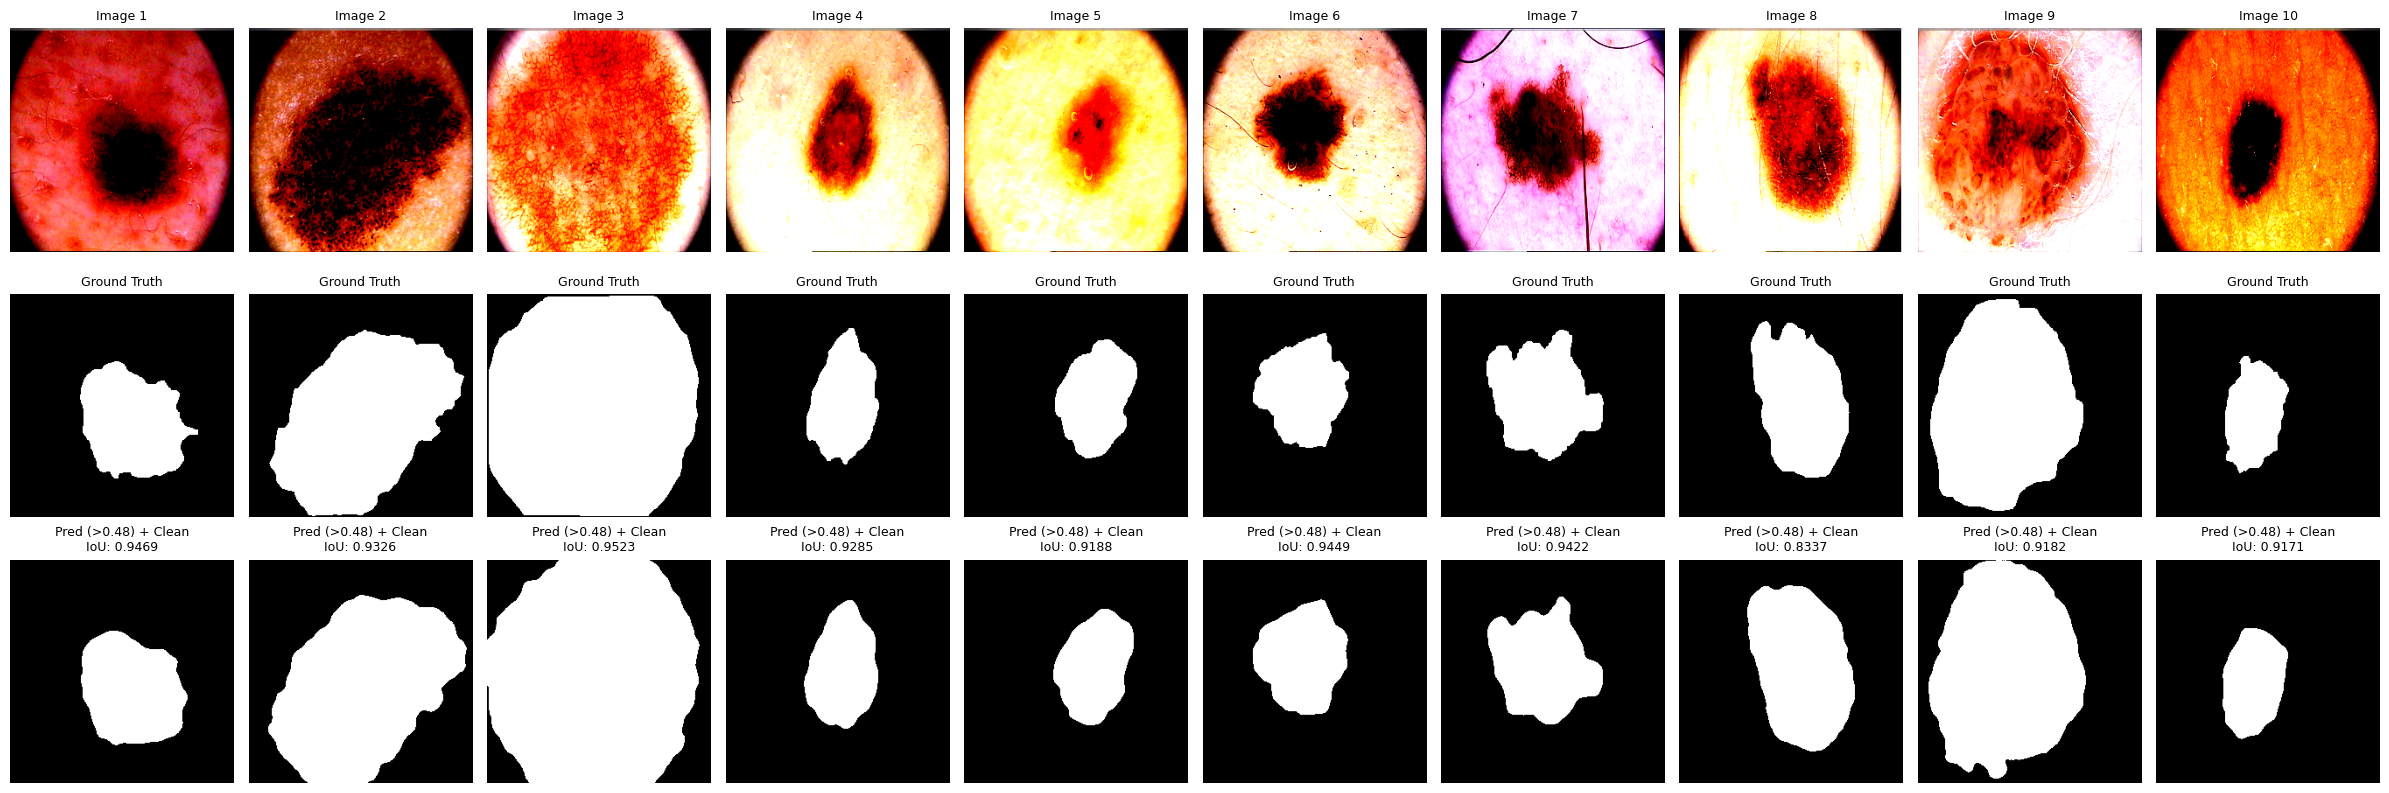

In [253]:
model.eval()

show_i_batch = 0

# Берем один тестовый батч
for i, (x_test, y_test) in enumerate(test_loader):
    if i != show_i_batch: continue
    x_test_gpu = x_test.to(device)

    with torch.no_grad():
        preds = tta_predict(model, x_test_gpu, device=device)

    # Отрисовываем первые 10 объектов (включая исходное фото)
    plot_result(x_images=x_test, y_true=y_test, predict=preds, num_samples=10, threshold=0.48, use_postprocess=True)

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

In [ ]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

In [ ]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    # TODO

    return loss

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)